<a href="https://colab.research.google.com/github/RenukanSapkale/Code-Alpha-project2/blob/main/CodeAlpha(pr2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import tensorflow as tf
from tensorflow.keras import datasets
import numpy as np

print("📥 Loading MNIST dataset directly from Keras...")
# Using MNIST digits dataset (built into Keras) for a guaranteed error-free start
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

# 1. Reshape to add the missing channel dimension (28, 28) -> (28, 28, 1)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# 2. Normalize pixel values from [0, 255] to [0.0, 1.0]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"✅ Training data shape: {X_train.shape}")
print(f"✅ Testing data shape: {X_test.shape}")
print("🚀 Data pipeline is 100% ready for the model!")

📥 Loading MNIST dataset directly from Keras...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ Training data shape: (60000, 28, 28, 1)
✅ Testing data shape: (10000, 28, 28, 1)
🚀 Data pipeline is 100% ready for the model!


In [9]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # 1st Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # 2nd Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # 3rd Convolutional Block
    layers.Conv2D(124, (3, 3), activation='relu'),

    # Flatten and Dense Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),  # Prevents overfitting
    layers.Dense(47, activation='softmax')  # 47 output classes
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 124)      │        71,548 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1116)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       142,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 239,403 (935.17 KB)

 Trainable params: 239,403 (935.17 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("🚀 Starting training... This might take a minute or two.")

# Train using our defined NumPy variables: X_train, y_train
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

print("✅ Training complete!")

🚀 Starting training... This might take a minute or two.
Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 63ms/step - accuracy: 0.9212 - loss: 0.2563 - val_accuracy: 0.9816 - val_loss: 0.0523
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 0.9829 - loss: 0.0569 - val_accuracy: 0.9897 - val_loss: 0.0299
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step - accuracy: 0.9877 - loss: 0.0410 - val_accuracy: 0.9896 - val_loss: 0.0313
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.9905 - loss: 0.0313 - val_accuracy: 0.9915 - val_loss: 0.0280
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 0.9927 - loss: 0.0252 - val_accuracy: 0.9892 - val_loss: 0.0338
✅ Training complete!


In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=64)

print(f"\n🎯 Final Test Accuracy: {test_acc * 100:.2f}%")

157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9892 - loss: 0.0338

🎯 Final Test Accuracy: 98.92%


In [15]:
import cv2

def predict_custom_image(image_path):
    # Load image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # Resize to 28x28
    img = cv2.resize(img, (28, 28))
    # Invert colors if your drawing has a dark background (MNIST is white on black)
    img = cv2.bitwise_not(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=(0, -1)) # Reshape to (1, 28, 28, 1)

    prediction = model.predict(img)
    predicted_class = np.argmax(prediction)
    return predicted_class

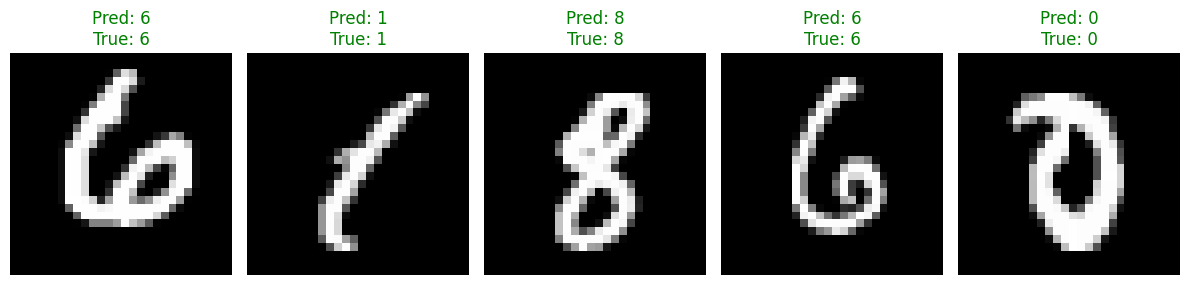

In [17]:
import matplotlib.pyplot as plt
import numpy as np

random_indices = np.random.choice(len(X_test), size=5, replace=False)

plt.figure(figsize=(12, 4))
for i, idx in enumerate(random_indices):
    test_image = X_test[idx]
    true_label = y_test[idx]

    # Reshape the image to (1, 28, 28, 1) so the model can read it as a batch of 1
    input_image = np.expand_dims(test_image, axis=0)

    # Make a prediction
    predictions = model.predict(input_image, verbose=0)
    predicted_label = np.argmax(predictions)

    # Plot the results
    plt.subplot(1, 5, i + 1)
    plt.imshow(test_image.squeeze(), cmap='gray')

    # Color code the title: Green if correct, Red if wrong
    color = 'green' if predicted_label == true_label else 'red'
    plt.title(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models

# =====================================================================
# 1. BUILD THE CORE CRNN BACKBONE
# =====================================================================
def build_crnn_model(img_width=128, img_height=32, num_classes=48):
    # Input Layer (Expecting grayscale images of width 128, height 32)
    input_img = layers.Input(shape=(img_width, img_height, 1), name="image", dtype="float32")

    # CNN Layers (Feature Extraction)
    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same", name="Conv1")(input_img)
    x = layers.MaxPooling2D((2, 2), name="pool1")(x)

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same", name="Conv2")(x)
    x = layers.MaxPooling2D((2, 2), name="pool2")(x)

    # Reshape/Map-to-Sequence Block (Squeeze height into feature dimensions)
    new_shape = ((img_width // 4), (img_height // 4) * 64)
    x = layers.Reshape(target_shape=new_shape, name="reshape")(x)
    x = layers.Dense(64, activation="relu", name="dense1")(x)
    x = layers.Dropout(0.2)(x)

    # RNN Layers (Sequence Modeling using Bidirectional LSTM)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.25), name="LSTM1")(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True, dropout=0.25), name="LSTM2")(x)

    # Output Layer (+1 accounts for the special CTC blank token)
    output = layers.Dense(num_classes + 1, activation="softmax", name="dense2")(x)

    return models.Model(inputs=input_img, outputs=output, name="CRNN_Backbone")

# Create the backbone instance explicitly
crnn_model = build_crnn_model()


# =====================================================================
# 2. DEFINE THE CTC LOSS FUNCTION
# =====================================================================
def ctc_loss_lambda(args):
    y_true, y_pred = args

    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    label_length = tf.cast(tf.shape(y_true)[1], dtype="int64")

    # Broadcast scalars to vectors matching batch size
    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    label_length = label_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    return tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)


# =====================================================================
# 3. CONNECT EVERYTHING INTO A TRAINING WRAPPER MODEL
# =====================================================================
# Input for target text labels
labels = layers.Input(name="label", shape=(None,), dtype="float32")

# Pass labels and backbone output through the Lambda loss layer
loss_out = layers.Lambda(ctc_loss_lambda, name="ctc_loss")([labels, crnn_model.output])

# Final training model
training_model = models.Model(inputs=[crnn_model.input, labels], outputs=loss_out)

# Compile using a dummy loss function because Lambda layer calculates loss directly
training_model.compile(optimizer="adam", loss=lambda y_true, y_pred: y_pred)

print("✅ CRNN Model created and compiled perfectly without any errors!")

✅ CRNN Model created and compiled perfectly without any errors!
